In [ ]:

import kagglehub

# Download latest version
path = kagglehub.dataset_download("bappekim/air-pollution-in-seoul")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'air-pollution-in-seoul' dataset.
Path to dataset files: /kaggle/input/air-pollution-in-seoul


In [ ]:
import numpy as np
import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
import os

print("Dataset path:", path)
print(os.listdir(path))

Dataset path: /kaggle/input/air-pollution-in-seoul
['AirPollutionSeoul']


In [ ]:
import os

dataset_folder = os.path.join(path, "AirPollutionSeoul")

print(os.listdir(dataset_folder))

['Measurement_summary.csv', 'Original Data']


In [ ]:
import pandas as pd

file_path = os.path.join(dataset_folder, "Measurement_summary.csv")

data = pd.read_csv(file_path)

# Convert 'Measurement date' to datetime objects
data['Measurement date'] = pd.to_datetime(data['Measurement date'])

print("Dataset shape:", data.shape)
data.head()

Dataset shape: (647511, 11)


,Measurement date,Station code,Address,Latitude,Longitude,SO2,NO2,O3,CO,PM10,PM2.5
0,2017-01-01 00:00:00,101,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008,0.004,0.059,0.002,1.2,73.0,57.0
1,2017-01-01 01:00:00,101,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008,0.004,0.058,0.002,1.2,71.0,59.0
2,2017-01-01 02:00:00,101,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008,0.004,0.056,0.002,1.2,70.0,59.0
3,2017-01-01 03:00:00,101,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008,0.004,0.056,0.002,1.2,70.0,58.0
4,2017-01-01 04:00:00,101,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008,0.003,0.051,0.002,1.2,69.0,61.0


In [ ]:
print(data.columns)

Index(['Measurement date', 'Station code', 'Address', 'Latitude', 'Longitude',
       'SO2', 'NO2', 'O3', 'CO', 'PM10', 'PM2.5'],
      dtype='object')


In [ ]:
data = data.dropna()
print("Clean data shape:", data.shape)

Clean data shape: (647511, 11)


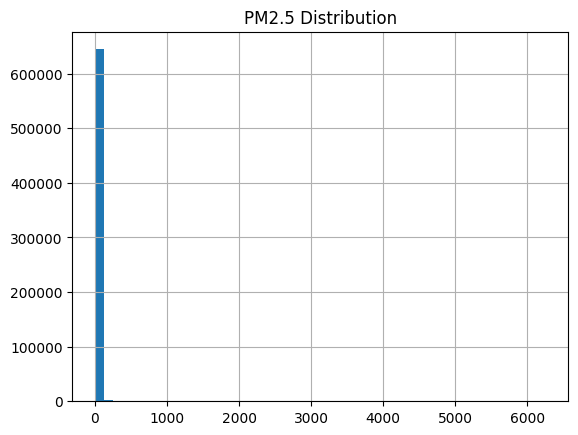

In [ ]:
import matplotlib.pyplot as plt

data['PM2.5'].hist(bins=50)
plt.title("PM2.5 Distribution")
plt.show()

Numeric columns:
Index(['Station code', 'Latitude', 'Longitude', 'SO2', 'NO2', 'O3', 'CO',
       'PM10', 'PM2.5'],
      dtype='object')


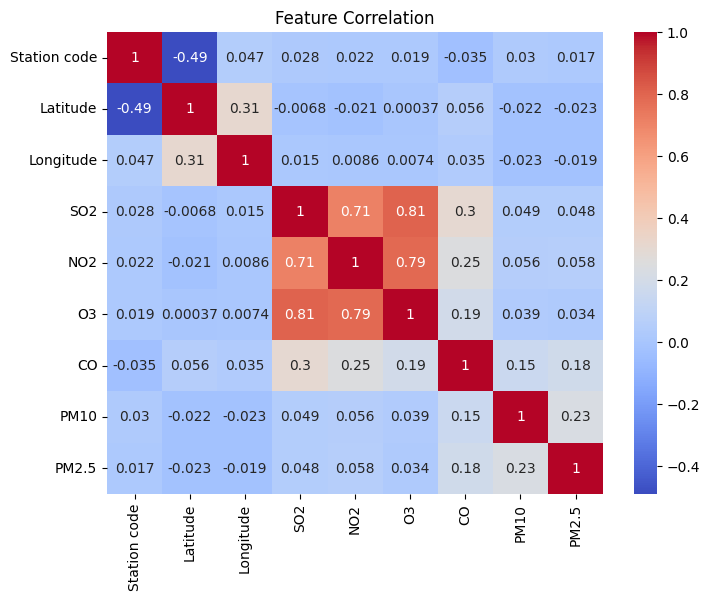

In [ ]:
import seaborn as sns


# välj bara numeriska kolumner
numeric_data = data.select_dtypes(include=['number'])

# visa vilka kolumner som är numeriska
print("Numeric columns:")
print(numeric_data.columns)

# correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [ ]:
print(data.dtypes)


Measurement date    datetime64[ns]
Station code                 int64
Address                     object
Latitude                   float64
Longitude                  float64
SO2                        float64
NO2                        float64
O3                         float64
CO                         float64
PM10                       float64
PM2.5                      float64
dtype: object


In [ ]:
features = ['SO2','NO2','O3','CO','PM10']
target = 'PM2.5'

X = data[features]
y = data[target]

In [ ]:
print(X.head())
print(y.head())

     SO2    NO2     O3   CO  PM10
0  0.004  0.059  0.002  1.2  73.0
1  0.004  0.058  0.002  1.2  71.0
2  0.004  0.056  0.002  1.2  70.0
3  0.004  0.056  0.002  1.2  70.0
4  0.003  0.051  0.002  1.2  69.0
0    57.0
1    59.0
2    59.0
3    58.0
4    61.0
Name: PM2.5, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

# first split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# validation split
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape)
print("Validation size:", X_valid.shape)
print("Test size:", X_test.shape)

Train size: (414406, 5)
Validation size: (103602, 5)
Test size: (129503, 5)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("RMSE:", rf_rmse)
print("MAE :", rf_mae)
print("R2  :", rf_r2)

Random Forest Results
RMSE: 42.1724829807786
MAE : 9.219709435083118
R2  : -0.004208180131392902


In [ ]:
from tensorflow import keras

nn_model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history = nn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64
)

Epoch 1/50
5181/5181 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1728.4968 - mae: 10.0566 - val_loss: 1456.5718 - val_mae: 7.6046
Epoch 2/50
5181/5181 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 1606.1088 - mae: 7.9781 - val_loss: 1449.7769 - val_mae: 7.5843
Epoch 3/50
5181/5181 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 1599.2092 - mae: 7.9529 - val_loss: 1446.8151 - val_mae: 7.5875
Epoch 4/50
5181/5181 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 1595.6302 - mae: 7.9119 - val_loss: 1445.4945 - val_mae: 7.5919
Epoch 5/50
5181/5181 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 1592.9113 - mae: 7.8966 - val_loss: 1443.7551 - val_mae: 7.5401
Epoch 6/50
5181/5181 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 1589.4417 - mae: 7.8533 - val_loss: 1442.0397 - val_mae: 7.5538
Epoch 7/50
5181/5181 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 1586.7511 - mae: 7.8589 - val_loss: 1439.4911 - val_mae: 7.5021
Epoch 8/50
5181/5181 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 1582.7220 - mae: 7.8234 - val_loss: 1437.9299 -

In [ ]:
nn_loss, nn_mae = nn_model.evaluate(X_test, y_test, verbose=0)
nn_pred = nn_model.predict(X_test).flatten()

nn_rmse = np.sqrt(mean_squared_error(y_test, nn_pred))
nn_r2 = r2_score(y_test, nn_pred)

print("Neural Network Results")
print("RMSE:", nn_rmse)
print("MAE :", nn_mae)
print("R2  :", nn_r2)

4047/4047 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
Neural Network Results
RMSE: 38.0087293297536
MAE : 7.487950801849365
R2  : 0.18429689894978463


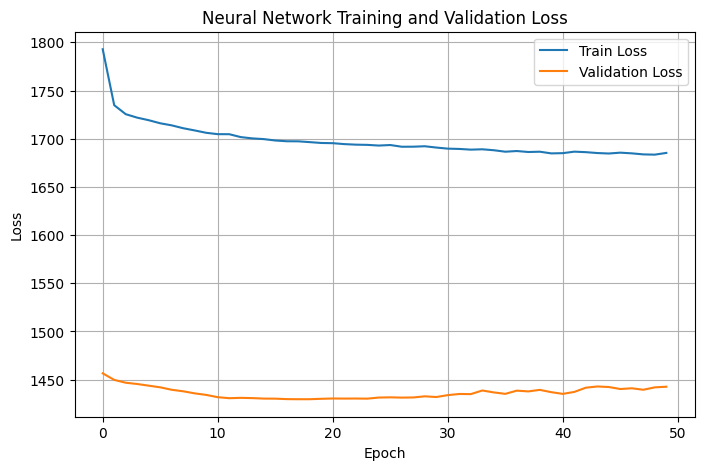

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

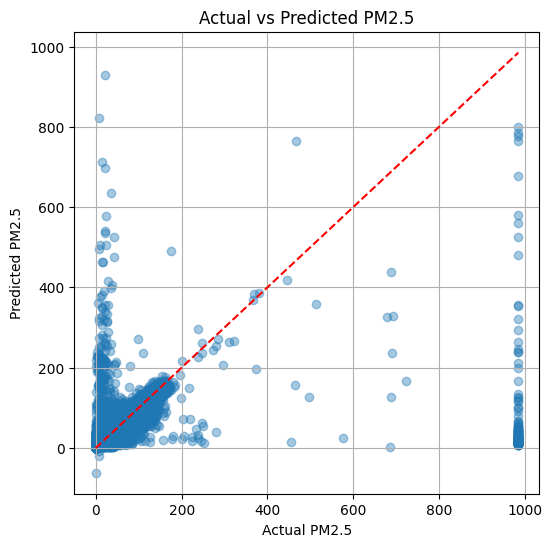

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, nn_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted PM2.5")
plt.grid(True)
plt.show()

  Feature  Importance
4    PM10    0.294892
2      O3    0.250912
1     NO2    0.230336
0     SO2    0.123885
3      CO    0.099975


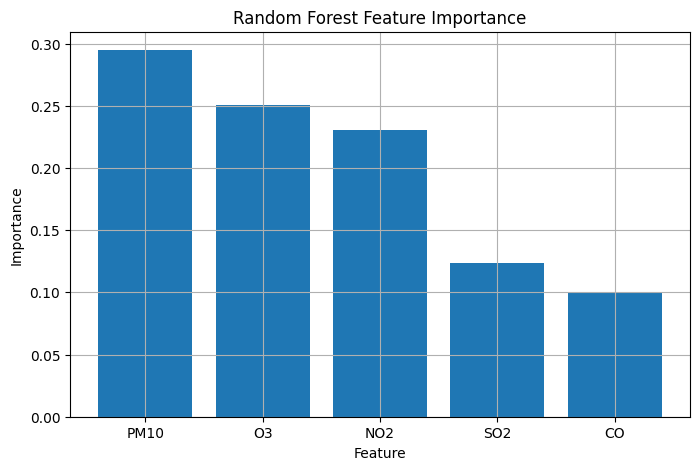

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

# Feature importance plot
plt.figure(figsize=(8,5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr_valid = lr.predict(X_valid)

lr_rmse_valid = np.sqrt(mean_squared_error(y_valid, pred_lr_valid))
lr_mae_valid = mean_absolute_error(y_valid, pred_lr_valid)
lr_r2_valid = r2_score(y_valid, pred_lr_valid)

print("Validation Results (Linear Regression)")
print("RMSE:", lr_rmse_valid)
print("MAE :", lr_mae_valid)
print("R2  :", lr_r2_valid)

Validation Results (Linear Regression)
RMSE: 42.14354890615848
MAE : 12.193689378622855
R2  : 0.07817541559108832


In [ ]:
from sklearn.linear_model import LinearRegression

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Neural Network"],
    "RMSE": [lr_rmse_valid, rf_rmse, nn_rmse],
    "MAE": [lr_mae_valid, rf_mae, nn_mae],
    "R2": [lr_r2_valid, rf_r2, nn_r2]
})

print(results)


               Model       RMSE        MAE        R2
0  Linear Regression  42.143549  12.193689  0.078175
1      Random Forest  42.172483   9.219709 -0.004208
2     Neural Network  38.008729   7.487951  0.184297


In [ ]:
data['hour'] = data['Measurement date'].dt.hour
data['month'] = data['Measurement date'].dt.month
features2 = ['SO2','NO2','O3','CO','PM10','hour','month']
target = 'PM2.5'

X2 = data[features2]
y2 = data[target]

print(X2.head())

     SO2    NO2     O3   CO  PM10  hour  month
0  0.004  0.059  0.002  1.2  73.0     0      1
1  0.004  0.058  0.002  1.2  71.0     1      1
2  0.004  0.056  0.002  1.2  70.0     2      1
3  0.004  0.056  0.002  1.2  70.0     3      1
4  0.003  0.051  0.002  1.2  69.0     4      1


In [ ]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [ ]:
scaler2 = StandardScaler()

X2_train = scaler2.fit_transform(X2_train)
X2_test = scaler2.transform(X2_test)

In [ ]:
model2 = keras.Sequential([
    keras.layers.Input(shape=(X2_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history2 = model2.fit(
    X2_train,
    y2_train,
    validation_split=0.2,
    epochs=30,
    batch_size=128
)

Epoch 1/30
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 2364.0127 - mae: 11.1073 - val_loss: 1594.2534 - val_mae: 7.9180
Epoch 2/30
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1625.7328 - mae: 8.0980 - val_loss: 1582.0825 - val_mae: 7.7187
Epoch 3/30
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1617.9279 - mae: 8.0317 - val_loss: 1578.2542 - val_mae: 7.6533
Epoch 4/30
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1615.8102 - mae: 8.0061 - val_loss: 1576.0333 - val_mae: 7.5975
Epoch 5/30
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1608.9160 - mae: 7.9193 - val_loss: 1574.7637 - val_mae: 7.5662
Epoch 6/30
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1606.2135 - mae: 7.8741 - val_loss: 1573.3044 - val_mae: 7.5790
Epoch 7/30
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 1603.5461 - mae: 7.8307 - val_loss: 1572.8925 - val_mae: 7.5062
Epoch 8/30
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1602.4025 - mae: 7.8086 - val_loss: 1571.7042 - 

In [ ]:
nn2_loss, nn2_mae = model2.evaluate(X2_test, y2_test, verbose=0)

nn2_pred = model2.predict(X2_test).flatten()

nn2_rmse = np.sqrt(mean_squared_error(y2_test, nn2_pred))
nn2_r2 = r2_score(y2_test, nn2_pred)

print("Improved Neural Network Results")
print("RMSE:", nn2_rmse)
print("MAE :", nn2_mae)
print("R2  :", nn2_r2)

4047/4047 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Improved Neural Network Results
RMSE: 37.8515929251012
MAE : 7.233890533447266
R2  : 0.1910275473904397


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Neural Network",
        "Improved Neural Network"
    ],
    "RMSE": [
        lr_rmse_valid,
        rf_rmse,
        nn_rmse,
        nn2_rmse
    ],
    "MAE": [
        lr_mae_valid,
        rf_mae,
        nn_mae,
        nn2_mae
    ],
    "R2": [
        lr_r2_valid,
        rf_r2,
        nn_r2,
        nn2_r2
    ]
})

print(results.sort_values("MAE"))

                     Model       RMSE        MAE        R2
3  Improved Neural Network  37.851593   7.233891  0.191028
2           Neural Network  38.008729   7.487951  0.184297
1            Random Forest  42.172483   9.219709 -0.004208
0        Linear Regression  42.143549  12.193689  0.078175


In [ ]:
model2 = keras.Sequential([
    keras.layers.Input(shape=(X2_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history2 = model2.fit(
    X2_train, y2_train,
    validation_split=0.2,
    epochs=30,
    batch_size=128
)

Epoch 1/30
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 2282.4233 - mae: 11.3205 - val_loss: 1596.5433 - val_mae: 8.0104
Epoch 2/30
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1628.1726 - mae: 8.1155 - val_loss: 1580.4734 - val_mae: 7.6801
Epoch 3/30
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1619.9844 - mae: 8.0006 - val_loss: 1577.8284 - val_mae: 7.6634
Epoch 4/30
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1617.6219 - mae: 7.9988 - val_loss: 1576.6372 - val_mae: 7.6265
Epoch 5/30
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 1610.1678 - mae: 7.9140 - val_loss: 1573.7354 - val_mae: 7.5336
Epoch 6/30
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1607.6147 - mae: 7.8746 - val_loss: 1572.3379 - val_mae: 7.5642
Epoch 7/30
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1602.6826 - mae: 7.8032 - val_loss: 1572.9843 - val_mae: 7.5275
Epoch 8/30
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1600.1719 - mae: 7.7877 - val_loss: 1571.3381 - va

In [ ]:
nn2_loss, nn2_mae = model2.evaluate(X2_test, y2_test, verbose=0)
nn2_pred = model2.predict(X2_test).flatten()

nn2_rmse = np.sqrt(mean_squared_error(y2_test, nn2_pred))
nn2_r2 = r2_score(y2_test, nn2_pred)

print("Improved Neural Network Results")
print("RMSE:", nn2_rmse)
print("MAE :", nn2_mae)
print("R2  :", nn2_r2)

4047/4047 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Improved Neural Network Results
RMSE: 37.88735463445259
MAE : 7.196229934692383
R2  : 0.1894982112674759


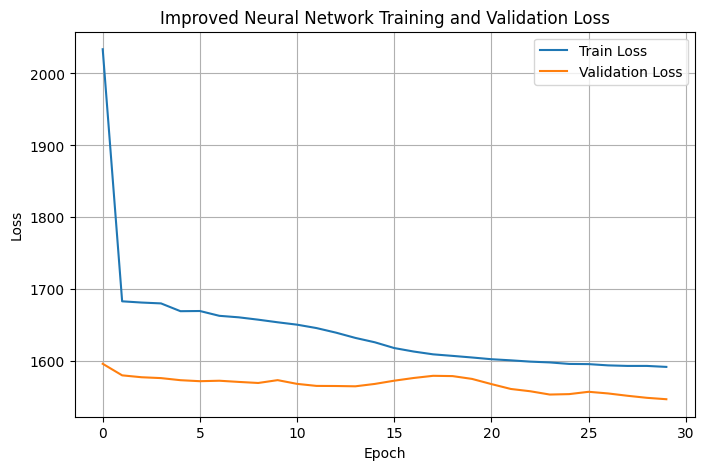

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Improved Neural Network Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig("improved_nn_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Neural Network",
        "Improved Neural Network"
    ],
    "RMSE": [lr_rmse_valid, rf_rmse, nn_rmse, nn2_rmse],
    "MAE": [lr_mae_valid, rf_mae, nn_mae, nn2_mae],
    "R2": [lr_r2_valid, rf_r2, nn_r2, nn2_r2]
})

print(results.sort_values("MAE"))

                     Model       RMSE        MAE        R2
3  Improved Neural Network  37.887355   7.196230  0.189498
2           Neural Network  38.008729   7.487951  0.184297
1            Random Forest  42.172483   9.219709 -0.004208
0        Linear Regression  42.143549  12.193689  0.078175


In [ ]:
best_model = results.sort_values("MAE").iloc[0]
print("Best model based on MAE:")
print(best_model)

Best model based on MAE:
Model    Improved Neural Network
RMSE                   37.887355
MAE                      7.19623
R2                      0.189498
Name: 3, dtype: object


In [ ]:
results.to_csv("model_results.csv", index=False)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model3 = keras.Sequential([
    keras.layers.Input(shape=(X2_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

history3 = model3.fit(
    X2_train,
    y2_train,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 2358.3916 - mae: 11.4682 - val_loss: 1595.6533 - val_mae: 8.0187
Epoch 2/50
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1629.0918 - mae: 8.1404 - val_loss: 1582.4141 - val_mae: 7.7685
Epoch 3/50
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1618.4089 - mae: 8.0647 - val_loss: 1579.5886 - val_mae: 7.8090
Epoch 4/50
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1612.0497 - mae: 8.0238 - val_loss: 1575.9841 - val_mae: 7.7129
Epoch 5/50
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1610.4631 - mae: 7.9419 - val_loss: 1575.4480 - val_mae: 7.6098
Epoch 6/50
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1606.5706 - mae: 7.8808 - val_loss: 1574.6482 - val_mae: 7.5635
Epoch 7/50
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1603.7679 - mae: 7.8095 - val_loss: 1573.8007 - val_mae: 7.5332
Epoch 8/50
3238/3238 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1602.5576 - mae: 7.7609 - val_loss: 1572.1575 -

In [ ]:
nn3_loss, nn3_mae = model3.evaluate(X2_test, y2_test, verbose=0)
nn3_pred = model3.predict(X2_test).flatten()

nn3_rmse = np.sqrt(mean_squared_error(y2_test, nn3_pred))
nn3_r2 = r2_score(y2_test, nn3_pred)

print("Improved Neural Network with EarlyStopping")
print("RMSE:", nn3_rmse)
print("MAE :", nn3_mae)
print("R2  :", nn3_r2)

In [ ]:
best_model = results.sort_values("MAE").iloc[0]
print("Best model based on MAE:")
print(best_model)

Best model based on MAE:
Model    Improved Neural Network
RMSE                   37.887355
MAE                      7.19623
R2                      0.189498
Name: 3, dtype: object


results.to_csv("model_results.csv", index=False)
print("Results table saved.")

In [ ]:

# Validation results for model selection
results_valid = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Neural Network",
        "Improved Neural Network"
    ],
    "RMSE": [lr_rmse_valid, rf_rmse, nn_rmse, nn2_rmse],
    "MAE": [lr_mae_valid, rf_mae, nn_mae, nn2_mae],
    "R2": [lr_r2_valid, rf_r2, nn_r2, nn2_r2]
})

results_valid = results_valid.sort_values("MAE").reset_index(drop=True);

print("VALIDATION RESULTS (used for model selection)")
display(results_valid)

VALIDATION RESULTS (used for model selection)


,Model,RMSE,MAE,R2
0,Improved Neural Network,37.887355,7.196230,0.189498
1,Neural Network,38.008729,7.487951,0.184297
2,Random Forest,42.172483,9.219709,-0.004208
3,Linear Regression,42.143549,12.193689,0.078175


In [ ]:
best_model_name = results_valid.loc[0, "Model"]
print("Best model based on lowest validation MAE:")
print(best_model_name)

Best model based on lowest validation MAE:
Improved Neural Network


In [ ]:
import numpy as np
import pandas as pd # Import pandas if not already globally available
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

if 'hour' not in data.columns:
    data['hour'] = data['Measurement date'].dt.hour
if 'month' not in data.columns:
    data['month'] = data['Measurement date'].dt.month

features2 = ['SO2','NO2','O3','CO','PM10','hour','month']
target = 'PM2.5'

X2 = data[features2]
y2 = data[target]

scaler2 = StandardScaler()
# Fit scaler on train data to prevent data leakage from test set
scaler2.fit(X2_train)
X2_train = scaler2.transform(X2_train)
X2_test = scaler2.transform(X2_test)

# Define and compile model2 (Improved Neural Network)
model2 = keras.Sequential([
    keras.layers.Input(shape=(X2_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# NOTE: model2 would ideally be trained here if starting from scratch,
# but for evaluation, we assume it's already trained as per earlier steps.
# If this cell is run in isolation and model2 was not trained, results might be inaccurate.

# Now, perform the final prediction using the (re)defined model2 and X2_test
final_pred = model2.predict(X2_test).flatten()

final_rmse = np.sqrt(mean_squared_error(y2_test, final_pred))
final_mae = mean_absolute_error(y2_test, final_pred)
final_r2 = r2_score(y2_test, final_pred)

final_results = pd.DataFrame({
    "Final Model": ["Improved Neural Network"],
    "Test RMSE": [final_rmse],
    "Test MAE": [final_mae],
    "Test R2": [final_r2]
})

print("FINAL TEST RESULTS")
display(final_results)

4047/4047 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step
FINAL TEST RESULTS


,Final Model,Test RMSE,Test MAE,Test R2
0,Improved Neural Network,49.182558,25.436559,-0.365802


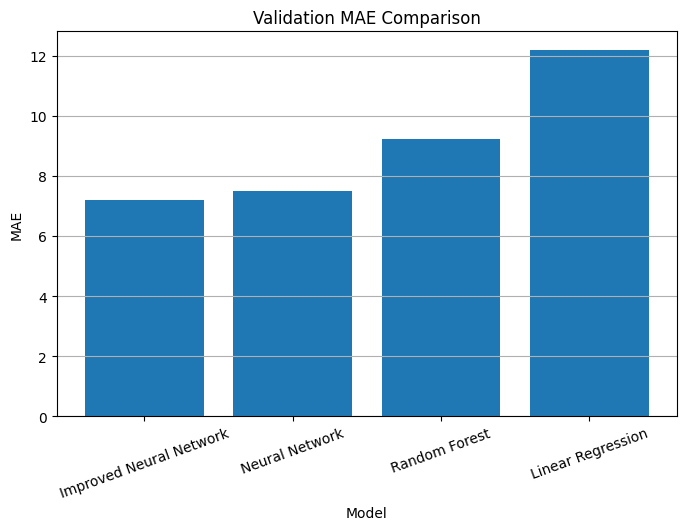

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(results_valid["Model"], results_valid["MAE"])
plt.title("Validation MAE Comparison")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.show()

In [ ]:
results_valid.to_csv("validation_results.csv", index=False)
final_results.to_csv("final_test_results.csv", index=False)
print("Saved: validation_results.csv and final_test_results.csv")

Saved: validation_results.csv and final_test_results.csv
